In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

from PIL import Image

from rec.utils import draw_bounding_boxes

In [3]:
BASE_PATH = "../code/rec/"

In [4]:
def get_concat_h(im1, im2):
    dst = Image.new('RGB', (im1.width + im2.width, im1.height))
    dst.paste(im1, (0, 0))
    dst.paste(im2, (im1.width, 0))
    return dst

### Read validation data

In [ ]:
df_valid_results = pd.read_parquet("../models/exp_004/predictions_val.parquet")

In [6]:
df_valid_results.head()

,bbox_raw,bbox_pred,img_filename,expr,hits,spatial,ordinal,relational,intrinsic
0,"[0.0, 0.0, 480.0, 360.0]","[118.66839, 115.8851, 331.78595, 322.0758]",refer/data/images/saiapr_tc-12/19/images/19135...,sky,0.0,0,0,0,1
1,"[173.0, 182.0, 448.0, 360.0]","[128.72174, 121.66016, 330.91086, 328.52045]",refer/data/images/saiapr_tc-12/19/images/19135...,statue,0.0,0,0,0,1
2,"[0.0, 380.0, 359.0, 480.0]","[73.13185, 212.2688, 265.48013, 365.41696]",refer/data/images/saiapr_tc-12/03/images/3096.jpg,the bottom fourth of the screen,0.0,1,1,1,0
3,"[0.0, 144.0, 360.0, 358.0]","[61.762352, 205.6637, 250.92838, 368.60434]",refer/data/images/saiapr_tc-12/27/images/27247...,ground back of people,0.0,1,0,0,0
4,"[195.0, 2.0, 358.0, 229.0]","[82.47853, 182.16629, 265.4039, 339.7757]",refer/data/images/saiapr_tc-12/03/images/3096.jpg,sky upper right,0.0,1,0,0,0


In [7]:
df_valid_results.shape

(65193, 9)

In [8]:
df_valid_results_exp003 = pd.read_parquet("../models/exp_003/predictions_val.parquet")

In [9]:
df_valid_results_exp003.head()

,bbox_raw,bbox_pred,img_filename,expr,hits,spatial,ordinal,relational,intrinsic
0,"[156.0, 169.0, 224.0, 360.0]","[151.18057, 165.33563, 211.10284, 359.0]",refer/data/images/saiapr_tc-12/10/images/10890...,person on the left,1.0,1,0,0,0
1,"[0.0, 94.0, 480.0, 360.0]","[19.449877, 49.38504, 479.0, 359.0]",refer/data/images/saiapr_tc-12/03/images/3593.jpg,the trees,1.0,0,0,0,1
2,"[110.0, 64.0, 296.0, 183.0]","[43.807602, 8.283485, 277.42676, 169.42986]",refer/data/images/saiapr_tc-12/03/images/3593.jpg,sky next to clouds,0.0,1,0,1,0
3,"[201.0, 49.0, 331.0, 184.0]","[175.06863, 75.22853, 302.1217, 181.43765]",refer/data/images/saiapr_tc-12/03/images/3593.jpg,clouds,1.0,0,0,0,1
4,"[176.0, 56.0, 478.0, 195.0]","[196.47316, 66.93359, 479.0, 192.50998]",refer/data/images/saiapr_tc-12/03/images/3593.jpg,mountain,1.0,0,0,0,1


In [10]:
df_valid_results = df_valid_results.join(df_valid_results_exp003.loc[:, ["bbox_pred"]], rsuffix='_exp003')

In [11]:
df_valid_results.head()

,bbox_raw,bbox_pred,img_filename,expr,hits,spatial,ordinal,relational,intrinsic,bbox_pred_exp003
0,"[0.0, 0.0, 480.0, 360.0]","[118.66839, 115.8851, 331.78595, 322.0758]",refer/data/images/saiapr_tc-12/19/images/19135...,sky,0.0,0,0,0,1,"[151.18057, 165.33563, 211.10284, 359.0]"
1,"[173.0, 182.0, 448.0, 360.0]","[128.72174, 121.66016, 330.91086, 328.52045]",refer/data/images/saiapr_tc-12/19/images/19135...,statue,0.0,0,0,0,1,"[19.449877, 49.38504, 479.0, 359.0]"
2,"[0.0, 380.0, 359.0, 480.0]","[73.13185, 212.2688, 265.48013, 365.41696]",refer/data/images/saiapr_tc-12/03/images/3096.jpg,the bottom fourth of the screen,0.0,1,1,1,0,"[43.807602, 8.283485, 277.42676, 169.42986]"
3,"[0.0, 144.0, 360.0, 358.0]","[61.762352, 205.6637, 250.92838, 368.60434]",refer/data/images/saiapr_tc-12/27/images/27247...,ground back of people,0.0,1,0,0,0,"[175.06863, 75.22853, 302.1217, 181.43765]"
4,"[195.0, 2.0, 358.0, 229.0]","[82.47853, 182.16629, 265.4039, 339.7757]",refer/data/images/saiapr_tc-12/03/images/3096.jpg,sky upper right,0.0,1,0,0,0,"[196.47316, 66.93359, 479.0, 192.50998]"


In [12]:
df_valid_results.loc[:, "sum_classes"] = df_valid_results.loc[:, ["spatial", "ordinal", "relational", "intrinsic"]].sum(axis=1)

Class: INTRINSIC, ../code/rec/refer/data/images/saiapr_tc-12/07/images/7355.jpg
signs


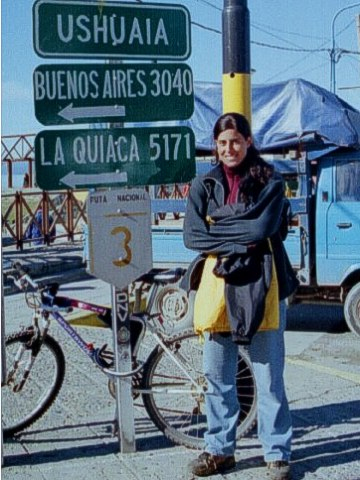

Class: INTRINSIC, ../code/rec/refer/data/images/saiapr_tc-12/27/images/27581.jpg
sky


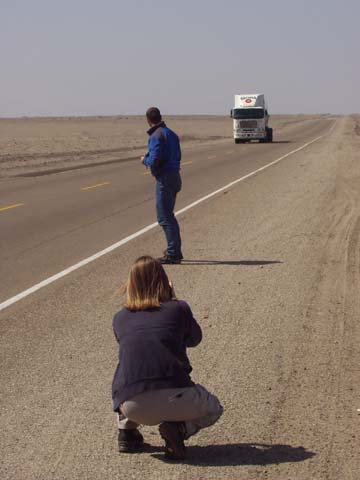

Class: INTRINSIC, ../code/rec/refer/data/images/saiapr_tc-12/22/images/22777.jpg
any grass


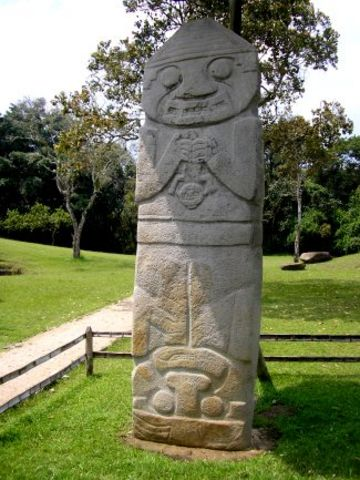

Class: INTRINSIC, ../code/rec/refer/data/images/saiapr_tc-12/22/images/22621.jpg
sky


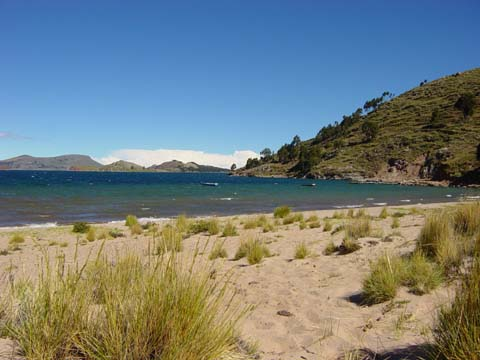

Class: INTRINSIC, ../code/rec/refer/data/images/saiapr_tc-12/39/images/39542.jpg
snow


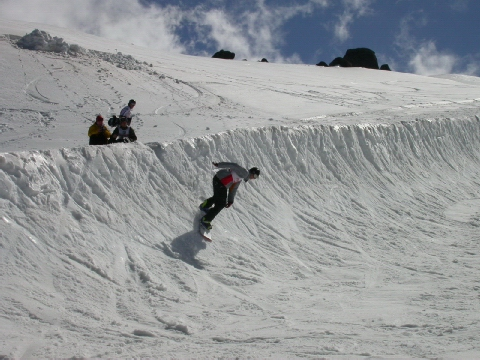

Class: INTRINSIC, ../code/rec/refer/data/images/saiapr_tc-12/39/images/39279.jpg
sky


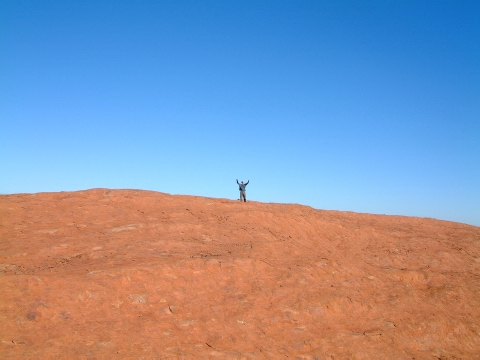

Class: INTRINSIC, ../code/rec/refer/data/images/saiapr_tc-12/37/images/37882.jpg
red guy


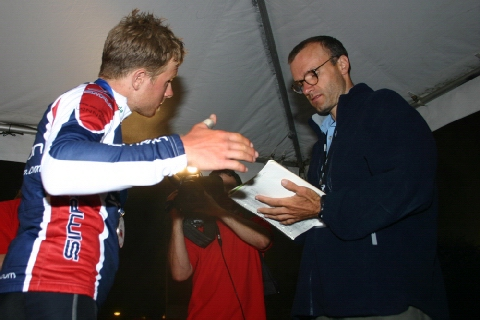

Class: INTRINSIC, ../code/rec/refer/data/images/saiapr_tc-12/40/images/40122.jpg
sky


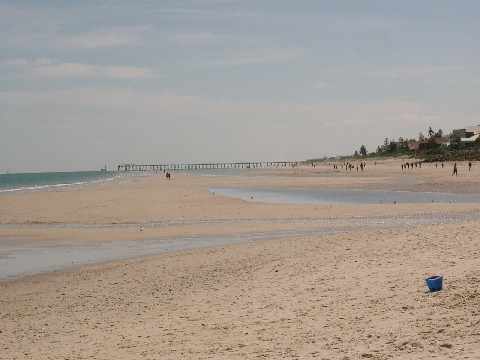

Class: INTRINSIC, ../code/rec/refer/data/images/saiapr_tc-12/07/images/7184.jpg
soda next togirl black shirt


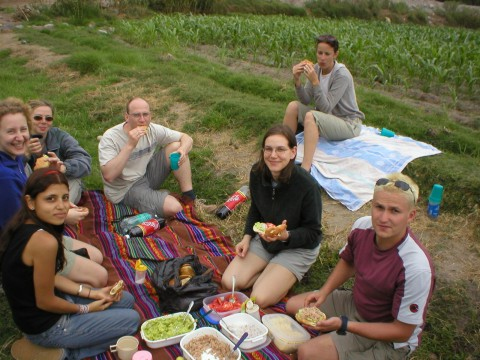

Class: INTRINSIC, ../code/rec/refer/data/images/saiapr_tc-12/11/images/11652.jpg
sky , really


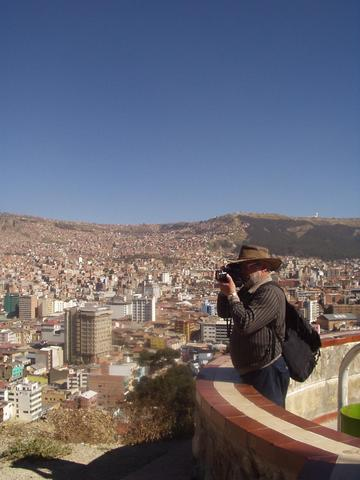

In [13]:
# Printing some samples of classes
color, lw = "lightgreen", 2
for rec_cls in ["intrinsic"]:
    df_sample_cls = df_valid_results.query(f"{rec_cls} == 1 and sum_classes == 1")
    df_sample_cls = df_sample_cls.sample(min(10, df_sample_cls.shape[0]), random_state=73)
    for _, row in df_sample_cls.loc[:, ["bbox_raw", "bbox_pred", "bbox_pred_exp003", "img_filename", "expr"]].iterrows():
        im = Image.open(f"{BASE_PATH}{row['img_filename']}")
        #im = draw_bounding_boxes(im, [row['bbox_raw']], fmt="xyxy", color=color, line_width=lw)
        print(f"Class: {rec_cls.upper()}, {BASE_PATH}{row['img_filename']}")
        print(row['expr'])
        im.show()

In [12]:
imgs_filenames = [
    'refer/data/images/saiapr_tc-12/08/images/8010.jpg', # spatial
    'refer/data/images/saiapr_tc-12/17/images/17723.jpg', # ordinal
    'refer/data/images/saiapr_tc-12/32/images/32036.jpg', # relational
    'refer/data/images/saiapr_tc-12/22/images/22645.jpg', # intrinsic
]
titles = [
    'left building', # spatial
    'first horse', # ordinal
    'the lights ontop the paiting', # relational
    'sky', # intrinsic
]
bboxes = [
    [0.0, 0.0, 80.0, 283.0],
    [371.0, 170.0, 453.0, 272.0],
    [211.0, 26.0, 278.0, 70.0],
    [0.0, 0.0, 363.0, 151.0]
]

In [54]:
def plot_4_rec_images(images_paths, titles, bboxes):
    fig, axs = plt.subplots(2, 2, figsize=(7, 7))
    size_img = (300, 300)
    img_path, title, bbox = images_paths[0], titles[0], bboxes[0]
    color = "lightgreen"
    img = Image.open(f"{BASE_PATH}{img_path}")
    img = draw_bounding_boxes(img, [bbox], fmt="xyxy", color=color, line_width=2)
    img = img.resize(size_img)
    axs[0, 0].imshow(img)
    axs[0, 0].set_title(title, fontsize=14)
    axs[0, 0].axis("off")

    img_path, title, bbox = images_paths[1], titles[1], bboxes[1]
    img = Image.open(f"{BASE_PATH}{img_path}")
    img = draw_bounding_boxes(img, [bbox], fmt="xyxy", color=color, line_width=2)
    img = img.resize(size_img)
    axs[0, 1].imshow(img)
    axs[0, 1].set_title(title, fontsize=14)
    axs[0, 1].axis("off")

    img_path, title, bbox = images_paths[2], titles[2], bboxes[2]
    img = Image.open(f"{BASE_PATH}{img_path}")
    img = draw_bounding_boxes(img, [bbox], fmt="xyxy", color=color, line_width=2)
    img = img.resize(size_img)
    axs[1, 0].imshow(img)
    axs[1, 0].set_title(title, fontsize=14)
    axs[1, 0].axis("off")

    img_path, title, bbox = images_paths[3], titles[3], bboxes[3]
    img = Image.open(f"{BASE_PATH}{img_path}")
    img = draw_bounding_boxes(img, [bbox], fmt="xyxy", color=color, line_width=2)
    img = img.resize(size_img)
    axs[1, 1].imshow(img)
    axs[1, 1].set_title(title, fontsize=14)
    axs[1, 1].axis("off")
    """
    |for img_path, title, bbox in zip(images_paths, titles, bboxes):
        img = Image.open(f"{BASE_PATH}{img_path}")
        img = draw_bounding_boxes(img, [bbox], fmt="xyxy", color="lightgreen")
        img = img.resize(size_img)
        ax.imshow(img)
        ax.set_title(title, fontsize=12)
        ax.axis("off")
    """
    plt.tight_layout()
    plt.show()

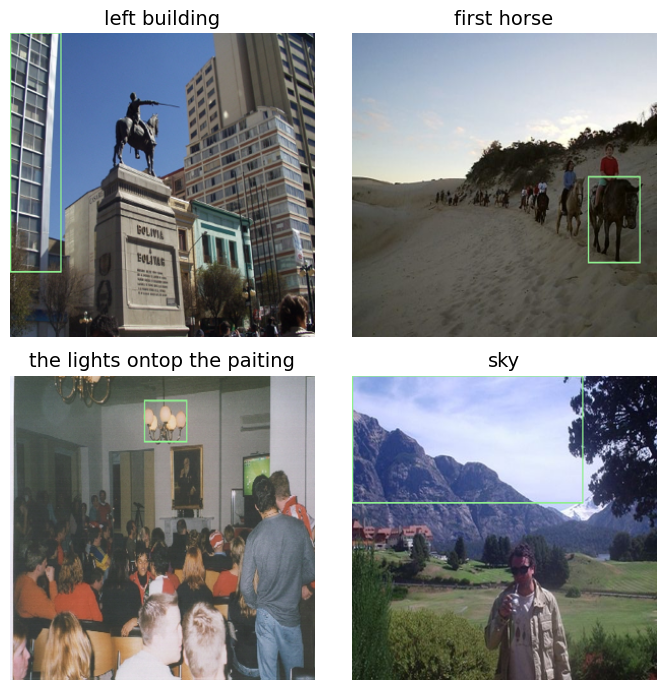

In [55]:
plot_4_rec_images(imgs_filenames, titles, bboxes)